# 무작위 상품 이미지 20장 확인

전체 `data/` 하위 이미지에서 seed 42로 20장을 추출합니다. 파일명과 EXIF 회전 전 원본 해상도(가로 × 세로)를 표시하고, 표시용 사본에 EXIF 방향 보정과 축소를 적용합니다. 원본 파일은 변경하지 않으며 OCR은 사용하지 않습니다.

실행 환경에 Pillow가 필요합니다. 없다면 현재 노트북 커널 환경에 `pip install Pillow`로 설치한 뒤 실행하세요.


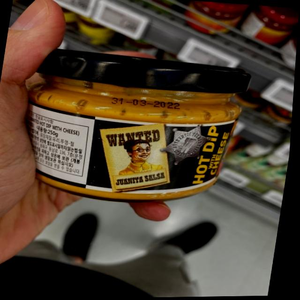
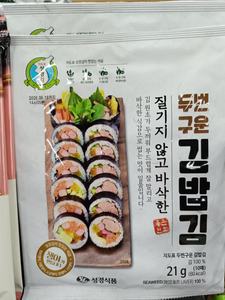
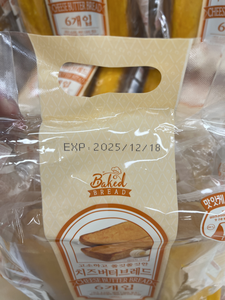
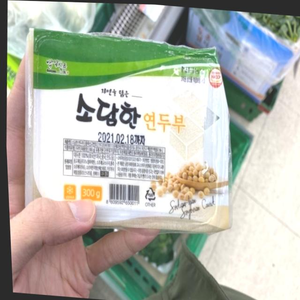
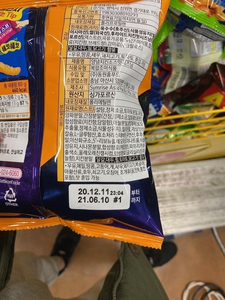
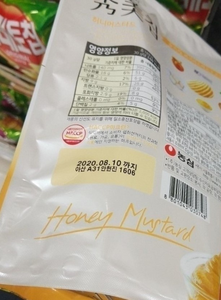
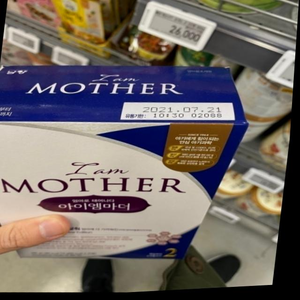
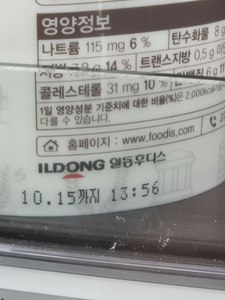
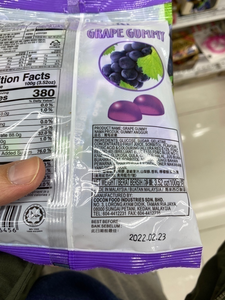
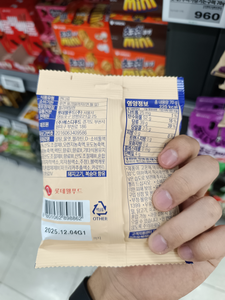
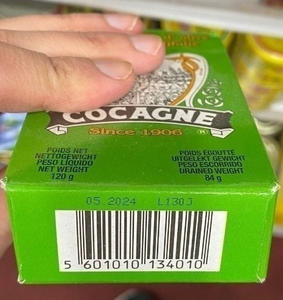
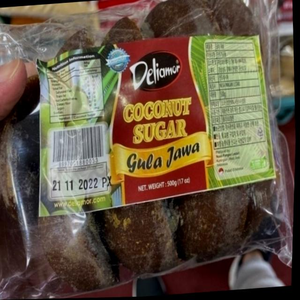
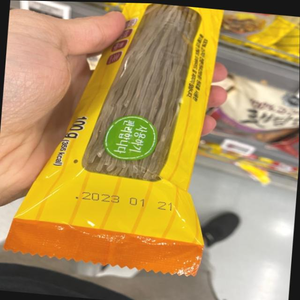
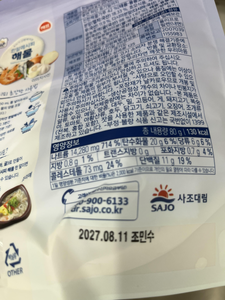
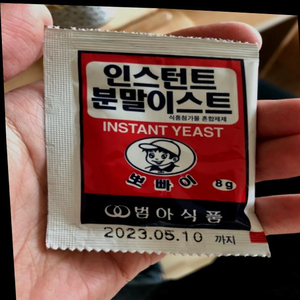
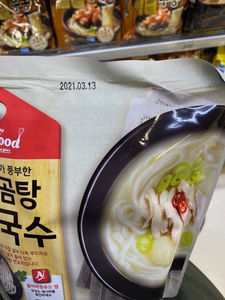
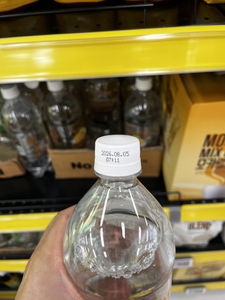
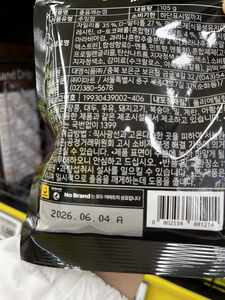
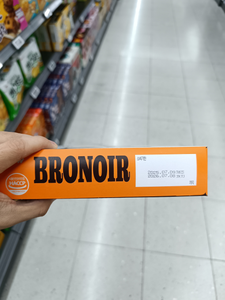
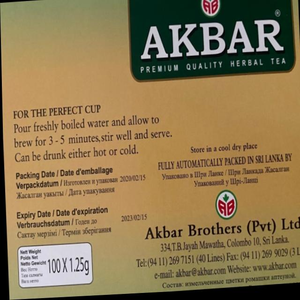

In [1]:
from pathlib import Path
import base64
import html
from io import BytesIO
import random

from PIL import Image, ImageOps
from IPython.display import HTML, display

SEED = 42
SAMPLE_COUNT = 20
DISPLAY_SIZE = (360, 300)
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff', '.webp'}

# 프로젝트 루트 또는 notebooks/에서 실행할 수 있습니다.
cwd = Path.cwd().resolve()
project_root = next((p for p in (cwd, *cwd.parents)
                     if (p / 'data').is_dir() and (p / 'predict.ipynb').is_file()), None)
if project_root is None:
    raise FileNotFoundError('프로젝트 루트 또는 notebooks/에서 실행해 주세요.')
data_dir = project_root / 'data'
image_paths = sorted(
    (p for p in data_dir.rglob('*') if p.is_file() and p.suffix.lower() in EXTENSIONS),
    key=lambda p: p.relative_to(data_dir).as_posix(),
)
if len(image_paths) < SAMPLE_COUNT:
    raise ValueError(f'이미지가 {SAMPLE_COUNT}장 이상 필요합니다. 현재: {len(image_paths)}장')
sample_paths = random.Random(SEED).sample(image_paths, SAMPLE_COUNT)

cards = []
for path in sample_paths:
    filename = html.escape(path.relative_to(data_dir).as_posix())
    original_size = None
    try:
        with Image.open(path) as original:
            original_size = original.size
            preview = ImageOps.exif_transpose(original)
            preview.thumbnail(DISPLAY_SIZE, Image.Resampling.LANCZOS)
            with BytesIO() as buffer:
                preview.convert('RGB').save(buffer, format='PNG')
                encoded = base64.b64encode(buffer.getvalue()).decode('ascii')
        body = (f'<img src="data:image/png;base64,{encoded}" alt="{filename}" '
                'style="max-width:100%;max-height:300px;object-fit:contain">')
    except Exception as exc:
        body = f'<span style="color:#b00020">읽기 오류: {html.escape(str(exc))}</span>'
    resolution = (f'{original_size[0]} × {original_size[1]} px'
                  if original_size is not None else '해상도 확인 불가')
    cards.append(
        '<div style="border:1px solid #ccc;padding:8px;min-width:0">'
        f'<div style="text-align:center;overflow-wrap:anywhere;margin-bottom:8px">'
        f'<strong>{filename}</strong><br>{resolution}</div>'
        f'<div style="height:300px;display:flex;align-items:center;justify-content:center">{body}</div>'
        '</div>'
    )

display(HTML(
    f'<p>전체 {len(image_paths):,}장 중 {SAMPLE_COUNT}장 · seed {SEED} · 원본 해상도: 가로 × 세로</p>'
    '<div style="display:grid;grid-template-columns:repeat(4,minmax(0,1fr));gap:12px">'
    + ''.join(cards) + '</div>'
))
